In [1]:
import shutil
import pandas as pd
import random

import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging

import os
import math # Import math for ceil
from sklearn.manifold import TSNE # Import TSNE to check default perplexity

import os
import glob
import json
import numpy as np
import tensorflow as tf
import sys
from itertools import zip_longest
import optuna
from sklearn import metrics

In [8]:
import sys
fixed_path = 'C:\\Users\\Enrico Didoli\\0.Master_Thesis\\'
#fixed_path = 'C:\\Users\\admin\\0.Master_Thesis\\'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

old_cellcnn_path = f'{fixed_path}Final_CellCNN/Old_CellCNN/'
if old_cellcnn_path not in sys.path:
    sys.path.append(old_cellcnn_path)

cellcnn_path = f'{fixed_path}Final_CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)
    
general_functions_path = f'{fixed_path}General_Functions/'
if general_functions_path not in sys.path:
    sys.path.append(general_functions_path)

save_path = f'{fixed_path}Final_CellCNN/results/'
if save_path not in sys.path:
    sys.path.append(save_path)

In [9]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid',
                'All_fixed_functions']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration


timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
new_datasets_generation rimosso dalla cache
run_models rimosso dalla cache
old_cellCnn.model rimosso dalla cache
old_cellCnn.utils rimosso dalla cache
old_cellCnn.downsample rimosso dalla cache
old_cellCnn.model_grid non trovato nella cache
All_fixed_functions non trovato nella cache


In [4]:
def remove_labels(new_test_datasets):
    new_no_label_test_datasets = []
    for dataset in new_test_datasets:
        if 'IsBlast' in dataset.columns:
            dataset = dataset.drop(columns = ['IsBlast'])
        
        new_no_label_test_datasets.append(dataset)
    print(len(new_no_label_test_datasets))
    return new_no_label_test_datasets

def show_blast_distribution_perc(ALL_DATASETS, return_perc = False):
    tot_perc_list = []
    for i, dataset in enumerate(ALL_DATASETS):
        blast_n = (dataset['IsBlast'] == 1).sum()
        tot_perc_list.append(round((blast_n/len(dataset))*100, 2))
    
    positions = range(1, len(tot_perc_list) + 1)
    
    fig, ax1 = plt.subplots(figsize = [len(positions)/2,4])
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), [max(tot_perc_list)]*len(tot_perc_list), alpha = 0.5)
    ax1.bar(list(range(1, len(tot_perc_list) + 1)), tot_perc_list)
    ax1.set_xticks(positions)
    
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    ax2.set_xticklabels(tot_perc_list, size = 'x-small')
    plt.show()

    if return_perc:
        return tot_perc_list

def show_blast_distribution_num(ALL_DATASETS, return_num = False):
    tot_perc_list = []
    for i, dataset in enumerate(ALL_DATASETS):
        blast_n = (dataset['IsBlast'] == 1).sum()
        tot_num_list.append(blast_n)
    
    positions = range(1, len(tot_num_list) + 1)
    
    fig, ax1 = plt.subplots(figsize = [len(positions)/2,4])
    ax1.bar(list(range(1, len(tot_num_list) + 1)), [max(tot_num_list)]*len(tot_num_list), alpha = 0.5)
    ax1.bar(list(range(1, len(tot_num_list) + 1)), tot_num_list)
    ax1.set_xticks(positions)
    
    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]
    
    ax2.set_xticklabels(tot_num_list, size = 'x-small')
    plt.show()

    if return_num:
        return tot_num_list

def grid_or_rand_model(grid):
    if grid:
        remove_from_cache(['old_cellCnn.model_grid'])
        from old_cellCnn.model_grid import CellCnn
    else:
        remove_from_cache(['old_cellCnn.model'])
        from old_cellCnn.model import CellCnn
    return CellCnn

def train_val_finalizing(train_datasets, val_datasets, grid, labels):
    """
    Renames rain and valdation sets.
    Removes Labels in case of grid search or no labels required.
    """
    if grid:
        train = remove_labels(train_datasets)
        val = remove_labels(val_datasets)
        print(f'_abels from Train and Validations Sets have been REMOVED.\nGrid Search Ready!')
    else:
        if not labels: # if random search but we don't want use labels
            train = remove_labels(train_datasets)
            val = remove_labels(val_datasets)
            print(f'labels from Train and Validations Sets have been REMOVED.\nRandom Search Ready!')
            
        else:
            train = train_datasets
            val = val_datasets
            print(f'Labels from Train and Validations Sets have been PRESERVED.\nRandom Search Ready!')
            
    return train, val

def prepare_results_to_save(results_list, par_list = ['config', 'model_sorted_idx']):
    """
    Construct a list of dictionaries to store predictions
    Each dictionary contains the configuration and the sorted runs for each trial
    """
    tot_trials_res = []

    for res in results_list:
        needed_results = {}
        for key, value in res.items():
            if key in par_list:
                needed_results[key] = value
                
        tot_trials_res.append(needed_results)
    return tot_trials_res

def retrieve_labels(datasets_extracted, remove = False, concat = False, flat = False):
    
    per_donor_original_datasets = []
    per_donor_original_y = []

    for donor in datasets_extracted:
        donor_datasets = []
        donor_ys = []
        for dataset in donor:
            if (dataset['IsBlast'] == 1).sum() > 0:
                donor_ys.append(1)
            else:
                donor_ys.append(0)
                
            if remove:
                dataset = dataset.drop(columns = ['IsBlast'])

            donor_datasets.append(dataset)

        if concat:
            per_donor_original_datasets += donor_datasets
            per_donor_original_y += donor_ys
        else:
            per_donor_original_datasets.append(donor_datasets)
            per_donor_original_y.append(donor_ys)


    if flat:
        per_donor_original_datasets = flatten(per_donor_original_datasets)
        per_donor_original_y = flatten(per_donor_original_y)
        
    return per_donor_original_datasets, per_donor_original_y 

def subset_sampling(dataset, ncells, nsubsets, seed):
    resampled_datasets = []
    resampled_y = []
    blast_perc = []
    
    for i in range(nsubsets):
        seed += 10
        #print(f'seed:{seed}')
        resampled_cells = dataset.sample(ncells, replace = True, random_state = seed).reset_index(drop=True) # sample cells
            
        if (resampled_cells['IsBlast'] == 1).sum() > 0: #check label
                resampled_y.append(1)
                blast_perc.append((resampled_cells[resampled_cells['IsBlast'] == 1]).sum()/len(resampled_cells))
        else:
                resampled_y .append(0)
                blast_perc.append(0)
        resampled_cells = resampled_cells.drop(columns = ['IsBlast']) #remove isblast column

        resampled_datasets.append(resampled_cells) 
    return    resampled_datasets,  resampled_y , blast_perc, seed


def get_timepoints_predictions(total_pred_lists, per_donor_original_test_y, threshold):
    total_labels = []
    
    for patient in total_pred_lists:
        patient_timepoints_labels = []
        
        for timepoint in patient:
            timepoint_f1_scores = []
            blast_labelled_timepoint_scores = []
            
            true_y = timepoint.iloc[-1]
            
            for trial in range(len(timepoint.iloc[:-1])): # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                sub = timepoint.iloc[trial]               # each sub is a pediction of the 20 samples of a single timepoint
                blast_labelled_perc = sub.sum()/len(true_y)
                blast_labelled_timepoint_scores.append(blast_labelled_perc) #percentage of timepoints labelled as with blast cells
     
            mean_timepoint_blast_score = np.mean(blast_labelled_timepoint_scores) # mean percentage of timepoints labelled as with blast cells
            
            if mean_timepoint_blast_score >= threshold*0.01:
                patient_timepoints_labels.append(1)
            else:
                patient_timepoints_labels.append(0)
                
        total_labels.append(patient_timepoints_labels)
    return total_labels


def get_trial_pred_per_timepoint(total_pred_lists, per_donor_original_test_y):
    plot_data = []
    boxplot_data = []
    total_timepoint_prediction_per_trial = []
    
    for patient, patient_ys in zip(total_pred_lists, per_donor_original_test_y):
        timepoint_prediction_per_trial = []
        
        for timepoint, true_timepoint_y in zip(patient, patient_ys):
            label_str = "Positive" if true_timepoint_y == 1 else "Negative"
            
            trial_level_label_prediction = []
            true_y = timepoint.iloc[-1]
            timepoint_boxplot_data = []
            
            for trial in range(len(timepoint.iloc[:-1])): # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                sub = timepoint.iloc[trial]               # each sub is a pediction of the 20 samples of a single timepoint
                
                trial_perc = sub.sum()/len(true_y)
                #trial_perc = sub.sum()/min(1, true_y.sum())
            
                #trial_level_label_prediction.append((blast_labelled_perc >= threshold*0.01).astype(int))
                plot_data.append({
                "True_Label": label_str,
                "Timepoint_Score": trial_perc
                })
                
                timepoint_boxplot_data.append(trial_perc)
                
            boxplot_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_boxplot_data
                })
                
    return plot_data, boxplot_data

def compute_timepoint_best_f1(timepoint_preds):
        """we are taking the best f1 score. because we are not tuning the model. we are just trying to predict the label of the timepoint"""
        timepoint_score = []
        
        resampled_true_y = timepoint_preds.iloc[-1] # get labels of resampled subsets
        #print(timepoint_preds.iloc[:-1]) #labels

        # initialize variables
        best_f1 = -1
        counter = 0
        
        for h in range(len(timepoint_preds) - 1):
            sub = timepoint_preds.iloc[h] # extrsct trial pediction
            
            f1 = f1_score(resampled_true_y, sub, pos_label = 1) # compute the f1_score
            if f1 > best_f1:
                best_f1_idx = counter
            counter += 1
            
        print(best_f1_idx)   
        best_sub = timepoint_preds.iloc[best_f1_idx]
        #print(len(true_y))
        blast_score = best_sub.sum() 
        print('')
        #print(best_sub)
        #print(f'blast_score: {blast_score}\n')
        timepoint_score = blast_score.sum()/len(resampled_true_y)
        return (timepoint_score, list(resampled_true_y))


def find_threshold(total_scores, per_donor_original_val_y):
    best_f1 = -1
    best_thr = -1
    tot_mean_f1_scores = []
    threshold_predictions = []
    for threshold in list(range(1,101)):
        f1_scores = []
        patient_predictions = []
        for patient_score, patient_y in zip(total_scores, per_donor_original_val_y):
            scores = []
            
            for timep in patient_score:
                # get mean columns predicted probabilities 
                scores.append(timep[0]) 
            
            y_pred = []
            y_pred = (np.array(scores) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
            #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')
            #print(patient_y)
            #print(y_pred)
            timepoint_f1_score = f1_score(patient_y, y_pred, pos_label = 1, zero_division=1)
            #print(f'f1_score: {timepoint_f1_score}\n')
        
            f1_scores.append(timepoint_f1_score)
            
            patient_predictions.append(list(y_pred))
            
        threshold_predictions.append(patient_predictions)
    
        #print(f1_scores)
        mean_f1_score = np.mean(f1_scores)
        tot_mean_f1_scores.append(mean_f1_score)
        
        if mean_f1_score > best_f1:
                best_f1 = mean_f1_score
                best_thr = threshold*0.01
        #print('')
    
        #patient_f1_scores.append(timepoint_f1_score)
    #plot thresholds
    plt.plot(list(range(1,101)), tot_mean_f1_scores)
    #for th in threshold_predictions:
        #print(th)

    #find threshold
    max_mean_f1 = max(tot_mean_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_mean_f1_scores) if f1 == max_mean_f1]
    #print(best_thresholds_idx)
    
    robust_best_thr_idx = np.median(best_thresholds_idx)
    #print(np.median(list(range(5))))
    print(f'Chosen threshold: {robust_best_thr_idx}' )
    return robust_best_thr_idx


def flatten(nested):
    if nested is None:
        return []
    if not isinstance(nested, (list, tuple)):
        return [nested]
    nested = list(nested)
    result = []
    for item in nested:
        result.extend(flatten(item))
    return result



def CV_train_val_splits(healthy_donors, blast_donors, mixed_donors,  test_donors_idx):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()
    
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)
    
    #print(h_pat, b_pat, m_pat)
    
    train_perm = []
    for hp in h_pat:
        for mp in m_pat:
            train_perm.append([hp, mp, b_pat[0], b_pat[1]])
            train_perm.append([hp, mp, b_pat[0], b_pat[2]])
            train_perm.append([hp, mp, b_pat[1], b_pat[2]])
    
    tot_train_val_perm = h_pat + b_pat + m_pat
    val_perm = []
    for element in train_perm:
        q = set(tot_train_val_perm.copy()) - set(element)
        val_perm.append(list(q))
    
    for t_fold, v_fold in zip(train_perm, val_perm):
        print(t_fold, v_fold)
    return train_perm, val_perm


def chosen_folds(iterations, train_perm, val_perm, seed = 42):
    print(seed)
    np.random.seed(seed)
    tot_perm = len(train_perm)
    
    idx = np.arange(tot_perm)
    np.random.shuffle(idx)

    chosen_folds = []
    for index in idx[:iterations]:
        chosen_folds.append([train_perm[index], val_perm[index]])
    
    return chosen_folds


def run_training(CellCnn, new_train_datasets, new_train_y, new_val_datasets, new_val_y, new_test_datasets, seed_list, hyper,
                             grid = True, labels = False, trials = 1, cells_per_sub = 200, best_nsub = 200):
    

    train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)
    new_test_datasets = flatten(new_test_datasets)
    test = remove_labels(new_test_datasets)
    no_label_val = remove_labels(new_val_datasets)

    models_lists = trials_train_CellCNN_old(CellCnn, train, #new_train_datasets_no_labels, 
                                  new_train_y, 
                                  val, #new_val_datasets_no_labels, 
                                  new_val_y, test, trials = trials,
                                  n_cell = cells_per_sub, nsubset = best_nsub,
                                  max_epochs=50, nrun=15, seed_list = seed_list, hyper = hyper)
    
    return models_lists

def val_res_pred(models_lists, per_donor_original_val_datasets, n, k, seed):
    per_donor_resampled_datasets =[]
    per_donor_resampled_y = []
    per_donor_perc = []
    
    mean_probs_per_patient = []
    total_pred_lists = []
    total_trial_pred_lists = []
    
    counter = 1
    for patient in per_donor_original_val_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
    
        timepoints_mean_probs = []
        patient_pred_list = []
        patient_trial_pred_list = []
        for file in patient:
            # for each dataset, multiple subsets of n cells are resampled
            resampled_datasets,  resampled_y , blast_perc, seed =  subset_sampling(file, ncells = n, nsubsets = k, seed = seed)
    
            print(f'Prediction {counter}')
            counter += 1
            new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
            positive_probs = []
            positive_probs_mean = []
            
            for trial in new_datasets_predictions_list:
                positive_probs.append(pd.DataFrame(trial)[1]) # appends the probability of positive classification
    
            all_trials_probs_array = np.array(positive_probs) #it converts the list of (list of) probabilities into an array of lists of probs
    
            # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
            positive_probs_mean = np.mean(all_trials_probs_array, axis=0)
    
            print(f'Len of Mean: {len(positive_probs_mean)}')
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(positive_probs) # stores all probabilities af all trials
    
            for trial in positive_probs_mean:
                print(trial)
            ## assigns mean probabilities to its true resampled subsets labels
            timepoints_mean_probs.append((positive_probs_mean, resampled_y))
            
        mean_probs_per_patient.append(timepoints_mean_probs)
        
        total_pred_lists.append(patient_pred_list)
        total_trial_pred_lists.append(patient_trial_pred_list)


    return total_pred_lists, total_trial_pred_lists, mean_probs_per_patient

def final_trials_prediction(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y, best_threshold):
    from sklearn.metrics import f1_score
    """ Elaborate data to show distribution of trial results over the entire set of timepoints and patiets"""
    prob_data = []
    f1_data = []
    boxplot_data = []
    
    for patient, patient_ys, patient_resampled_y in zip(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y):

        for timepoint, true_timepoint_y, true_resampled_y in zip(patient, patient_ys, patient_resampled_y):
            label_str = "Positive" if true_timepoint_y == 1 else "Negative"
            
            timepoint_boxplot_data = []
            timepoint_f1_data = []
            #print(timepoint)
            for trial in timepoint: # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                             # each sub is a pediction of the 20 samples of a single timepoint

                #print(trial)
                trial_prob = np.mean(trial) # mean of the probabilities of the subsets
                
                trial_pred = (np.array(trial) >= best_threshold*0.01).astype(int)
                #print(trial_pred)
                #print(true_resampled_y)
                
                trial_f1 =  f1_score(true_resampled_y, trial_pred, pos_label = 1, zero_division=1)
                #print(rqver)
                
                prob_data.append({
                "True_Label": label_str,
                "Timepoint_Score": trial_prob
                })
                
                
                timepoint_boxplot_data.append(trial_prob)
                timepoint_f1_data.append(trial_f1)
                
            boxplot_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_boxplot_data
                })
            
            f1_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_f1_data
                })
                
    return prob_data, boxplot_data, f1_data

def test_res_pred(models_lists, per_donor_original_test_datasets, n, k, seed, best_threshold, trials):
    
    counter = 1
    per_donor_resampled_test_datasets =[]
    per_donor_resampled_test_y = []
    per_donor_perc = []
    
    test_total_labels = []
    test_total_pred_lists = []
    test_total_trial_pred_lists = []
    
    for patient in per_donor_original_test_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
        patient_timepoints_labels = []
        patient_pred_list = []
        patient_trial_pred_list = []
        
        for file in patient:
            sub_division = sub_resampling_list(k, nsub_per_sub = 50)
            print(sub_division)
            total_resampled_y = []
            total_positive_probs = [[] for _ in range(len(models_lists))]
            print(total_positive_probs)
            division_positive_probs_mean = []
            print(f'Prediction {counter}')
            counter += 1
            
            for _, division in enumerate(sub_division):
                print(division)
                resampled_datasets, resampled_y, blast_perc, seed = subset_sampling(dataset = file, ncells = n, nsubsets = division, seed = seed)
                
                # predict labels 
                new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
                positive_probs = []
                
                """ Extraction and mean probabilities section """
                for iterat, trial in enumerate(new_datasets_predictions_list):
                    positive_probs.append(pd.DataFrame(trial)[1].values) # appends the probability of positive classification
                    total_positive_probs[iterat] += list(pd.DataFrame(trial)[1].values)
        
                 #it converts the list of (list of) probabilities into an array of lists of prob
                
                # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
                division_positive_probs_mean.append(np.mean(positive_probs , axis=0))
                
                total_resampled_y += resampled_y

            positive_probs_mean = np.concatenate(division_positive_probs_mean)
            #print(f'Len of Mean: {len(positive_probs_mean)}')
            #print(f'Len of probs: {len(total_positive_probs)}')
            """ Threshold prediction section """
            mean_timepoint_probs = np.mean(positive_probs_mean) # mean percentage of timepoints labelled as with blast cells
                
            if mean_timepoint_probs >= best_threshold*0.01:
                    patient_timepoints_labels.append(1)
            else:
                    patient_timepoints_labels.append(0)
            
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(total_positive_probs) # stores all probabilities af all trials
            
            per_dataset_resampled_ys.append(total_resampled_y)
            
        test_total_labels.append(patient_timepoints_labels)
        test_total_pred_lists.append(patient_pred_list)
        
        test_total_trial_pred_lists.append(patient_trial_pred_list)
        per_donor_resampled_test_y.append(per_dataset_resampled_ys)
    
    return test_total_labels, test_total_pred_lists, test_total_trial_pred_lists, per_donor_resampled_test_y

def sub_resampling_list(k, nsub_per_sub = 50):
    remaining_k = k
    sub_division = []
    
    while remaining_k > 0:
        print(remaining_k)
        if remaining_k >= nsub_per_sub:
            sub_division.append(nsub_per_sub)
            remaining_k -= nsub_per_sub
            print(sub_division)
        else:
            sub_division.append(remaining_k)
            return sub_division
    return sub_division
'''

def find_robust_threshold(mean_probs_per_patient):

    
    best_f1 = -1
    best_thr = -1
    tot_per_tr_f1_scores = []
    threshold_predictions = []
    
    for threshold in list(range(1,101)):

        """ Concatenate mean probs and labels into two nsubset x timepoints lists """
        f1_scores = []
        patient_predictions = []
        resampled_ys = []
        probs = []
        for patient_probs_tuple in mean_probs_per_patient:
            
            for timep, timep_res_y in patient_probs_tuple:
                
                # get mean columns predicted probabilities 
                probs += list(timep)
                
                # get the resampled ys
                resampled_ys += list(timep_res_y)

        #print('Log: Concatenation: Done!')
            
        y_pred = []
        y_pred = (np.array(probs) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
        #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')

        # compute f1 score on the concatenated timepoints results 
        total_f1_score = f1_score(resampled_ys, y_pred, pos_label = 1, zero_division=1)
        #print(f'f1_score: {total_f1_score}\n')
        
        tot_per_tr_f1_scores.append(total_f1_score) # Visualization purposes
        
        if total_f1_score > best_f1:
                best_f1 = total_f1_score
                best_thr = threshold*0.01
        #print('')
    
    """ Best Threshold selection section """
    #find threshold
    max_f1 = max(tot_per_tr_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_per_tr_f1_scores) if f1 == max_f1]

    # whether multiple threholds provides the maximum f1_score, the median is taken
    best_threshold = np.median(best_thresholds_idx)
    print(best_threshold)
    plt.plot(list(range(1, 101)), tot_per_tr_f1_scores)
    plt.vlines(x=best_threshold + 1, ymin = 0, ymax = 1, color='red', linestyle='--')
    print(f'Chosen threshold: {best_threshold + 1}. Associated F1_score: {tot_per_tr_f1_scores[int(best_threshold)]}' )
    
    return best_threshold + 1, tot_per_tr_f1_scores
'''

def retrieve_nsub_models_names(n_sub_tuning_path):
    """ Retrieve nsub folders names """

    def extract_num(folder_name):
        if 'model_' in folder_name:
            return folder_name
    # get folder_names
    n_sub_cartelle = [
        nome for nome in os.listdir(n_sub_tuning_path)
        if os.path.isdir(os.path.join(n_sub_tuning_path , nome))]
    
    n_sub_models = [
        extract_num(model) for model in n_sub_cartelle 
        if extract_num(model) is not None]
    
    return n_sub_models

def generate_seeds(n = 10, seed = None):
    """ Generate seed list """
    if seed is None:
        print('Warning: random generation. No Reproducibility!')
        print('Reproducibility -> add "seed:int()" parameter!')
    else:
        np.random.seed(seed)
    return np.random.choice(10**6, n)

def find_best_nsubs(f1_step_1, nsub_list, n = 5, indices = False):
    """ Returns the n nsub values that performed best. If multiple values have the highest f1_score, higher values are prefered"""
    
    idx = np.argsort(f1_step_1) # fi_step_1 elements' indices ordered in acscending order (the last element is the index of the best element in f1_step_1)
    unique_values = np.sort(list(set(f1_step_1.copy()))) #sort function returns the sorted uniques values of a list

    f1_5_best, best_5_idx = [], []
    for value in unique_values[::-1]:
        counter = len(f1_step_1) - 1
        
        for element in f1_step_1[::-1]: 
            
            if element == value:
                f1_5_best.append(element)
                best_5_idx.append(counter)
                
            if len(best_5_idx) == n:
                print(f'5 best f1_score values: {f1_5_best} at indexes: {best_5_idx}')

                if indices: 
                    return np.sort(np.array(nsub_list)[best_5_idx]), best_5_idx
                else:
                    return np.sort(np.array(nsub_list)[best_5_idx])
                
            counter -= 1
    return



def val_res_pred(models_lists, per_donor_original_val_datasets, n, k, seed):
    per_donor_resampled_datasets =[]
    per_donor_resampled_y = []
    per_donor_perc = []
    
    mean_probs_per_patient = []
    total_pred_lists = []
    total_trial_pred_lists = []
    
    counter = 1
    for patient in per_donor_original_val_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
    
        timepoints_mean_probs = []
        patient_pred_list = []
        patient_trial_pred_list = []
        for file in patient:
            # for each dataset, multiple subsets of n cells are resampled
            resampled_datasets,  resampled_y , blast_perc, seed =  subset_sampling(file, ncells = n, nsubsets = k, seed = seed)
    
            print(f'Prediction {counter}')
            counter += 1
            new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
            positive_probs = []
            positive_probs_mean = []
            
            for trial in new_datasets_predictions_list:
                positive_probs.append(pd.DataFrame(trial)[1]) # appends the probability of positive classification
    
            all_trials_probs_array = np.array(positive_probs) #it converts the list of (list of) probabilities into an array of lists of probs
    
            # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
            positive_probs_mean = np.mean(all_trials_probs_array, axis=0)
    
            print(f'Len of Mean: {len(positive_probs_mean)}')
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(positive_probs) # stores all probabilities af all trials
    
            for trial in positive_probs_mean:
                print(trial)
            ## assigns mean probabilities to its true resampled subsets labels
            timepoints_mean_probs.append((positive_probs_mean, resampled_y))
            
        mean_probs_per_patient.append(timepoints_mean_probs)
        
        total_pred_lists.append(patient_pred_list)
        total_trial_pred_lists.append(patient_trial_pred_list)


    return total_pred_lists, total_trial_pred_lists, mean_probs_per_patient

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
'''
def find_robust_threshold(mean_probs_per_patient, metric = 'f1', closest = False):

    if metric == 'f1':
        metric_score = f1_score
    elif metric == 'recall':
        metric_score = recall_score
    elif metric == 'roc':
        metric_score = roc_auc_score
    elif metric == 'accuracy':
        metric_score = accuracy_score
    elif metric == 'precision':
        metric_score = precision_score
        
    best_f1 = -1
    best_thr = -1
    tot_per_tr_f1_scores = []
    threshold_predictions = []
    
    for threshold in list(range(1,101)):

        """ Concatenate mean probs and labels into two nsubset x timepoints lists """
        f1_scores = []
        patient_predictions = []
        resampled_ys = []
        probs = []
        for patient_probs_tuple in mean_probs_per_patient:
            
            for timep, timep_res_y in patient_probs_tuple:
                
                # get mean columns predicted probabilities 
                probs += list(timep)
                
                # get the resampled ys
                resampled_ys += list(timep_res_y)

        #print('Log: Concatenation: Done!')
            
        y_pred = []
        y_pred = (np.array(probs) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
        #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')

        # compute f1 score on the concatenated timepoints results
        if metric in ['f1', 'recall', 'precision']:
            total_f1_score = metric_score(resampled_ys, y_pred, pos_label = 1, zero_division=1)
        else:
            total_f1_score = metric_score(resampled_ys, y_pred)
        #print(f'f1_score: {total_f1_score}\n')
        
        tot_per_tr_f1_scores.append(total_f1_score) # Visualization purposes
        
        if total_f1_score > best_f1:
                best_f1 = total_f1_score
                best_thr = threshold*0.01
        #print('')
    
    """ Best Threshold selection section """
    #find threshold
    max_f1 = max(tot_per_tr_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_per_tr_f1_scores) if f1 == max_f1]

    # whether multiple threholds provides the maximum f1_score, the median is taken
    best_threshold = np.median(best_thresholds_idx) + 1

                
    print(best_threshold)
    plt.plot(list(range(1, 101)), tot_per_tr_f1_scores)
    plt.vlines(x=best_threshold1, ymin = 0, ymax = 1, color='red', linestyle='--')
    print(f'Chosen threshold: {best_threshold}. Associated F1_score: {tot_per_tr_f1_scores[int(best_threshold - 1)]}' )
    
    return best_threshold, tot_per_tr_f1_scores
'''

def sub_resampling_list(k, nsub_per_sub = 50):
    remaining_k = k
    sub_division = []
    
    while remaining_k > 0:
        print(remaining_k)
        if remaining_k >= nsub_per_sub:
            sub_division.append(nsub_per_sub)
            remaining_k -= nsub_per_sub
            print(sub_division)
        else:
            sub_division.append(remaining_k)
            return sub_division
    return sub_division
            

def test_res_pred(models_lists, per_donor_original_test_datasets, n, k, seed, best_threshold, trials):
    
    counter = 1
    per_donor_resampled_test_datasets =[]
    per_donor_resampled_test_y = []
    per_donor_perc = []
    
    test_total_labels = []
    test_total_pred_lists = []
    test_total_trial_pred_lists = []
    
    for patient in per_donor_original_test_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
        patient_timepoints_labels = []
        patient_pred_list = []
        patient_trial_pred_list = []
        
        for file in patient:
            sub_division = sub_resampling_list(k, nsub_per_sub = 50)
            print(sub_division)
            total_resampled_y = []
            total_positive_probs = [[] for _ in range(trials)]
            print(total_positive_probs)
            division_positive_probs_mean = []
            print(f'Prediction {counter}')
            counter += 1
            
            for _, division in enumerate(sub_division):
                print(division)
                resampled_datasets, resampled_y, blast_perc, seed = subset_sampling(dataset = file, ncells = n, nsubsets = division, seed = seed)
                
                # predict labels 
                new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
                positive_probs = []
                
                """ Extraction and mean probabilities section """
                for iterat, trial in enumerate(new_datasets_predictions_list):
                    positive_probs.append(pd.DataFrame(trial)[1].values) # appends the probability of positive classification
                    total_positive_probs[iterat] += list(pd.DataFrame(trial)[1].values)
        
                 #it converts the list of (list of) probabilities into an array of lists of prob
                
                # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
                division_positive_probs_mean.append(np.mean(positive_probs , axis=0))
                
                total_resampled_y += resampled_y

            positive_probs_mean = np.concatenate(division_positive_probs_mean)
            #print(f'Len of Mean: {len(positive_probs_mean)}')
            #print(f'Len of probs: {len(total_positive_probs)}')
            """ Threshold prediction section """
            mean_timepoint_probs = np.mean(positive_probs_mean) # mean percentage of timepoints labelled as with blast cells
                
            if mean_timepoint_probs >= best_threshold*0.01:
                    patient_timepoints_labels.append(1)
            else:
                    patient_timepoints_labels.append(0)
            
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(total_positive_probs) # stores all probabilities af all trials
            
            per_dataset_resampled_ys.append(total_resampled_y)
            
        test_total_labels.append(patient_timepoints_labels)
        test_total_pred_lists.append(patient_pred_list)
        
        test_total_trial_pred_lists.append(patient_trial_pred_list)
        per_donor_resampled_test_y.append(per_dataset_resampled_ys)
    
    return test_total_labels, test_total_pred_lists, test_total_trial_pred_lists, per_donor_resampled_test_y
    




def val_res_pred(models_lists, per_donor_original_val_datasets, n, k, seed):
    per_donor_resampled_datasets =[]
    per_donor_resampled_y = []
    per_donor_perc = []
    
    mean_probs_per_patient = []
    total_pred_lists = []
    total_trial_pred_lists = []
    
    counter = 1
    for patient in per_donor_original_val_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
    
        timepoints_mean_probs = []
        patient_pred_list = []
        patient_trial_pred_list = []
        for file in patient:
            # for each dataset, multiple subsets of n cells are resampled
            resampled_datasets,  resampled_y , blast_perc, seed =  subset_sampling(file, ncells = n, nsubsets = k, seed = seed)
    
            print(f'Prediction {counter}')
            counter += 1
            new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
            positive_probs = []
            positive_probs_mean = []
            
            for trial in new_datasets_predictions_list:
                positive_probs.append(pd.DataFrame(trial)[1]) # appends the probability of positive classification
    
            all_trials_probs_array = np.array(positive_probs) #it converts the list of (list of) probabilities into an array of lists of probs
    
            # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
            positive_probs_mean = np.mean(all_trials_probs_array, axis=0)
    
            print(f'Len of Mean: {len(positive_probs_mean)}')
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(positive_probs) # stores all probabilities af all trials
    
            for trial in positive_probs_mean:
                print(trial)
            ## assigns mean probabilities to its true resampled subsets labels
            timepoints_mean_probs.append((positive_probs_mean, resampled_y))
            
        mean_probs_per_patient.append(timepoints_mean_probs)
        
        total_pred_lists.append(patient_pred_list)
        total_trial_pred_lists.append(patient_trial_pred_list)


    return total_pred_lists, total_trial_pred_lists, mean_probs_per_patient

from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

def find_robust_threshold(mean_probs_per_patient, metric = 'f1', closest = False):

    if metric == 'f1':
        metric_score = f1_score
    elif metric == 'recall':
        metric_score = recall_score
    elif metric == 'roc':
        metric_score = roc_auc_score
    elif metric == 'accuracy':
        metric_score = accuracy_score
    elif metric == 'precision':
        metric_score = precision_score
        
    best_f1 = -1
    best_thr = -1
    tot_per_tr_f1_scores = []
    threshold_predictions = []
    
    for threshold in list(range(1,101)):

        """ Concatenate mean probs and labels into two nsubset x timepoints lists """
        f1_scores = []
        patient_predictions = []
        resampled_ys = []
        probs = []
        for patient_probs_tuple in mean_probs_per_patient:
            
            for timep, timep_res_y in patient_probs_tuple:
                
                # get mean columns predicted probabilities 
                probs += list(timep)
                
                # get the resampled ys
                resampled_ys += list(timep_res_y)

        #print('Log: Concatenation: Done!')
            
        y_pred = []
        y_pred = (np.array(probs) >= threshold*0.01).astype(int) #checks column by column if the element is > than the threshold and converts it in 1 or 0
        #print(f'Threshold: {threshold*0.01}. Preds: {y_pred}')

        # compute f1 score on the concatenated timepoints results
        if metric in ['f1', 'recall', 'precision']:
            total_f1_score = metric_score(resampled_ys, y_pred, pos_label = 1, zero_division=1)
        else:
            total_f1_score = metric_score(resampled_ys, y_pred)
        #print(f'f1_score: {total_f1_score}\n')
        
        tot_per_tr_f1_scores.append(total_f1_score) # Visualization purposes
        
        if total_f1_score > best_f1:
                best_f1 = total_f1_score
                best_thr = threshold*0.01
        #print('')
    
    """ Best Threshold selection section """
    #find threshold
    max_f1 = max(tot_per_tr_f1_scores)
    best_thresholds_idx = []
    
    best_thresholds_idx = [i for i, f1 in enumerate(tot_per_tr_f1_scores) if f1 == max_f1]

    # whether multiple threholds provides the maximum f1_score, the median is taken
    best_threshold = np.median(best_thresholds_idx) + 1

    print(tot_per_tr_f1_scores)
    
    lowest_distance = 100
    thr_distances = []
    if closest:
        print(np.array(tot_per_tr_f1_scores)[best_thresholds_idx])
        for thr_idx in np.array(list(range(1,101)))[best_thresholds_idx]:
            thr_dist = abs(thr_idx - 50)
            if thr_dist < lowest_distance:
                thr_distances.append(thr_dist)
                
        min_dist_thr_idx = thr_distances.index(np.min(thr_distances))
        best_threshold = np.array(list(range(1,101)))[best_thresholds_idx][min_dist_thr_idx]
                
    print(best_threshold)
    plt.plot(list(range(1, 101)), tot_per_tr_f1_scores)
    plt.vlines(x=best_threshold, ymin = 0, ymax = 1, color='red', linestyle='--')
    print(f'Chosen threshold: {best_threshold}. Associated F1_score: {tot_per_tr_f1_scores[int(best_threshold - 1)]}' )
    
    return best_threshold, tot_per_tr_f1_scores


def sub_resampling_list(k, nsub_per_sub = 50):
    remaining_k = k
    sub_division = []
    
    while remaining_k > 0:
        print(remaining_k)
        if remaining_k >= nsub_per_sub:
            sub_division.append(nsub_per_sub)
            remaining_k -= nsub_per_sub
            print(sub_division)
        else:
            sub_division.append(remaining_k)
            return sub_division
    return sub_division
            

def test_res_pred(models_lists, per_donor_original_test_datasets, n, k, seed, best_threshold, trials):
    
    counter = 1
    per_donor_resampled_test_datasets =[]
    per_donor_resampled_test_y = []
    per_donor_perc = []
    
    test_total_labels = []
    test_total_pred_lists = []
    test_total_trial_pred_lists = []
    
    for patient in per_donor_original_test_datasets:
        per_dataset_resampled_datasets = []
        per_dataset_resampled_ys = []
        per_dataset_perc = []
        patient_timepoints_labels = []
        patient_pred_list = []
        patient_trial_pred_list = []
        
        for file in patient:
            sub_division = sub_resampling_list(k, nsub_per_sub = 50)
            print(sub_division)
            total_resampled_y = []
            total_positive_probs = [[] for _ in range(trials)]
            print(total_positive_probs)
            division_positive_probs_mean = []
            print(f'Prediction {counter}')
            counter += 1
            
            for _, division in enumerate(sub_division):
                print(division)
                resampled_datasets, resampled_y, blast_perc, seed = subset_sampling(dataset = file, ncells = n, nsubsets = division, seed = seed)
                
                # predict labels 
                new_datasets_predictions_list, new_datasets_results_list = trials_test_CellCNN_old(models_lists, resampled_datasets)
                positive_probs = []
                
                """ Extraction and mean probabilities section """
                for iterat, trial in enumerate(new_datasets_predictions_list):
                    positive_probs.append(pd.DataFrame(trial)[1].values) # appends the probability of positive classification
                    total_positive_probs[iterat] += list(pd.DataFrame(trial)[1].values)
        
                 #it converts the list of (list of) probabilities into an array of lists of prob
                
                # Computes the mean over the columns ( it takes the first element of all arrays and make the mean, then the second and so on)
                division_positive_probs_mean.append(np.mean(positive_probs , axis=0))
                
                total_resampled_y += resampled_y

            positive_probs_mean = np.concatenate(division_positive_probs_mean)
            #print(f'Len of Mean: {len(positive_probs_mean)}')
            #print(f'Len of probs: {len(total_positive_probs)}')
            """ Threshold prediction section """
            mean_timepoint_probs = np.mean(positive_probs_mean) # mean percentage of timepoints labelled as with blast cells
                
            if mean_timepoint_probs >= best_threshold*0.01:
                    patient_timepoints_labels.append(1)
            else:
                    patient_timepoints_labels.append(0)
            
            
            patient_pred_list.append(positive_probs_mean) # stores the mean subset probabilities
            patient_trial_pred_list.append(total_positive_probs) # stores all probabilities af all trials
            
            per_dataset_resampled_ys.append(total_resampled_y)
            
        test_total_labels.append(patient_timepoints_labels)
        test_total_pred_lists.append(patient_pred_list)
        
        test_total_trial_pred_lists.append(patient_trial_pred_list)
        per_donor_resampled_test_y.append(per_dataset_resampled_ys)
    
    return test_total_labels, test_total_pred_lists, test_total_trial_pred_lists, per_donor_resampled_test_y
    
# classical CV 3 fold
def remove_test_patients_from_categories(healthy_donors, blast_donors, mixed_donors,  test_donors_idx):
    h_pat, b_pat, m_pat = healthy_donors.copy(), blast_donors.copy(), mixed_donors.copy()

    # remove patients in the external test set from the three patient categories
    tot_pat = []
    for pat in test_donors_idx:
        if pat in healthy_donors:
            h_pat.remove(pat)
        if pat in blast_donors:
             b_pat.remove(pat)
        if pat in mixed_donors:
            m_pat.remove(pat)

    

    # generate the entire list of patients to split
    tot_pat = []
    for pat_1, pat_2, pat_3 in zip_longest(h_pat, b_pat, m_pat, fillvalue=None):
        # Only add non-None values (or whatever fillvalue you choose)
        if pat_1 is not None:
            tot_pat.append(pat_1)
        if pat_2 is not None:
            tot_pat.append(pat_2)
        if pat_3 is not None:
            tot_pat.append(pat_3)
    
    print(f'Remaining Patients: healthy = {h_pat}, unhealthy = {b_pat}, mixed = {m_pat}')
    print(f'All Patients in Train + Validation set: {tot_pat}')
    return h_pat, b_pat, m_pat, tot_pat

def LOOCV_division(tot_pat):
    LOOCV_folds = []
    for i, fold in enumerate(tot_pat):
        test = [fold]
        train = [sub_fold for sub_fold in tot_pat if fold != sub_fold]
        LOOCV_folds.append((train, test))
        print(train, test)
    print('')
    return LOOCV_folds
'''    
def classic_CV_train_val_splits(h_pat, b_pat, m_pat, tot_pat, folds = 3, LOOCV_test = None):
    # if present, remove the test patient from h,b,m sets
    if LOOCV_test is not None:
        if LOOCV_test[0] in h_pat: #healthy
            h_pat = [pat for pat in h_pat if pat != LOOCV_test[0]]
        elif LOOCV_test[0] in b_pat: #unhealthy
            b_pat = [pat for pat in b_pat if pat != LOOCV_test[0]]
        elif LOOCV_test[0] in m_pat: #mixed
            m_pat = [pat for pat in m_pat if pat != LOOCV_test[0]]
            
    sub_len = int(len(tot_pat)/folds) # len of each fold
    print(f'Minimum number of patients in each fold: {sub_len}')

    # store the three different patietns' folds
    single_folds = []
    counter = 0
    for fold in range(folds - 1): 
        single_folds.append(tot_pat[counter: counter + sub_len])
        counter += sub_len
    single_folds.append(tot_pat[counter:])
    print(f'Folds: {single_folds}')

    # finally make the n train-validation combinations
    tot_folds = []
    for n_fold in range(folds):
        val_fold = single_folds[n_fold - 1]
        train_fold = []
        for fold in single_folds:
            if fold != val_fold:
                train_fold += fold
                
        print(f'Combination {n_fold + 1}: {train_fold, val_fold}')
        tot_folds.append([train_fold, val_fold])
    return tot_folds
'''
def generate_seeds(n = 10, seed = None):
    """ Generate seed list """
    if seed is None:
        print('Warning: random generation. No Reproducibility!')
        print('Reproducibility -> add "seed:int()" parameter!')
    else:
        np.random.seed(seed)
    return np.random.choice(10**6, n)



In [5]:
import sys
import numpy as np
import pandas as pd

def get_actual_size(obj):
    """Get TRUE memory size"""
    if isinstance(obj, pd.DataFrame):
        return obj.memory_usage(deep=True).sum()
    elif isinstance(obj, pd.Series):
        return obj.memory_usage(deep=True)
    elif isinstance(obj, np.ndarray):
        return obj.nbytes
    elif isinstance(obj, (list, tuple, set, dict)):
        # For containers, sum up contents
        return sys.getsizeof(obj) + sum(sys.getsizeof(item) for item in obj)
    else:
        return sys.getsizeof(obj)

def print_var_memory(var_to_check = None):
    # Display all variables with ACTUAL sizes
    all_vars = %who_ls
    sizes = []
    if var_to_check is None:
        var_to_check = all_vars

    
    for var_name in all_vars:
        #try:
            var = eval(var_name)
           
            #if var_name in  ('train_datasets_extracted','val_datasets_extracted','test_datasets_extracted'):
            if var_name in var_to_check:
                #print(var)
                if isinstance(var, (list, tuple)):
                    var = flatten(var)
                    tot = 0
                    for element in var:
                        tot += get_actual_size(element)
                    size = tot
                    sizes.append((var_name, type(var).__name__, size))
            else:
                size = get_actual_size(var)
                sizes.append((var_name, type(var).__name__, size))
        
        #except:
        #    pass
    
    # Sort by size
    sizes.sort(key=lambda x: x[2], reverse=True)
    
    # Pretty print
    print(f"{'Variable':<25} {'Type':<20} {'Memory':>15}")
    print("-" * 65)
    total = 0
    var_to_check = []
    for name, type_name, size in sizes:
        total += size
        if size > 1024**3:  # GB
            print(f"{name:<25} {type_name:<20} {size/(1024**3):>12.2f} GB")
            var_to_check.append(name)
            
        elif size > 1024**2:  # MB
            print(f"{name:<25} {type_name:<20} {size/(1024**2):>12.2f} MB")
            var_to_check.append(name)
        '''
        elif size > 1024:  # KB
            print(f"{name:<25} {type_name:<20} {size/1024:>12.2f} KB")
        
        else:
            print(f"{name:<25} {type_name:<20} {size:>12} bytes")
        '''
    print("-" * 65)
    print(f"{'TOTAL':<25} {'':<20} {total/(1024**3):>12.2f} GB")
    return var_to_check
    
print_var_memory()

Variable                  Type                          Memory
-----------------------------------------------------------------
-----------------------------------------------------------------
TOTAL                                                  0.00 GB


[]

In [49]:

def strat_CV(h_pat, b_pat, m_pat, shuffle = False, seed = None):
    """ Custom stratified CV. Builded to work with heatlhy, unhealthy and mixed patients"""
    
    print(h_pat, b_pat, m_pat)
    if shuffle:
        if seed:
            np.random.seed(seed)
        np.random.shuffle(h_pat)
        np.random.shuffle(b_pat)
        np.random.shuffle(m_pat)
        print(h_pat, b_pat, m_pat)

    # divide patients
    patients_division = []
    for h, b, m in zip_longest(h_pat, b_pat, m_pat):
        f = [h, b, m]
        while None in f:
            f.remove(None)
        patients_division.append(f)

    # build folds
    folds = []
    counter = 0
    for _ in patients_division:
        val = patients_division[counter]
        train = patients_division.copy()
        train.remove(val)
        folds.append([flatten(train), val])
        counter += 1
    return folds


from itertools import zip_longest
def classic_CV_train_val_splits(h_pat, b_pat, m_pat, tot_pat, folds = 3, LOOCV_test = None, shuffle_seed = None):
    # if present, remove the test patient from h,b,m sets
    #print(f'LOOCV_test: {LOOCV_test}')
    if LOOCV_test is not None:
        if str(LOOCV_test) in h_pat: #healthy
            h_pat = [pat for pat in h_pat if pat != str(LOOCV_test)]
        elif str(LOOCV_test) in b_pat: #unhealthy
            b_pat = [pat for pat in b_pat if pat != str(LOOCV_test)]
        elif str(LOOCV_test) in m_pat: #mixed
            m_pat = [pat for pat in m_pat if pat != str(LOOCV_test)]

        tot_pat = []
        for pat_1, pat_2, pat_3 in zip_longest(h_pat, b_pat, m_pat, fillvalue=None):
            # Only add non-None values (or whatever fillvalue you choose)
            if pat_1 is not None:
                tot_pat.append(pat_1)
            if pat_2 is not None:
                tot_pat.append(pat_2)
            if pat_3 is not None:
                tot_pat.append(pat_3)

    sub_len = int(len(tot_pat)/folds) # len of each fold
    print(f'Minimum number of patients in each fold: {sub_len}')

    if shuffle_seed is not None:
        np.random.seed(shuffle_seed)
        np.random.shuffle(tot_pat)
    # store the three different patietns' folds
    single_folds = []
    counter = 0
    len_counter = 0
    for fold in range(folds - 1):
        len_counter += len(tot_pat)/folds
        diff =  int(len_counter - counter)
        single_folds.append(tot_pat[counter: counter + diff])
        counter += diff
    single_folds.append(tot_pat[counter:])
    print(f'Folds: {single_folds}')

    # finally make the n train-validation combinations
    tot_folds = []
    for n_fold in range(folds):
        val_fold = single_folds[n_fold - 1]
        train_fold = []
        for fold in single_folds:
            if fold != val_fold:
                train_fold += fold

        print(f'Combination {n_fold + 1}: {train_fold, val_fold}')
        tot_folds.append([train_fold, val_fold])
    return tot_folds

def extract_fold_features(chosen_perm):
        # retireve files' id from fold patient division
    fold_features = {}
    for i, (train_set, val_set) in enumerate(chosen_perm):
    
        ##### Train #####
        # extract files from patients' id
        set_train_files, set_val_files = [], []
        for train_pat in train_set:
            train_files = multiple_donations[train_pat]
            set_train_files += train_files # indexes of files in ALL_DATASETS list
    
        
        train_file_perc = list(np.array(tot_perc_list)[set_train_files]) # extracts only the interested file pecentages
        train_features = [train_set, train_file_perc, np.mean(train_file_perc), np.std(train_file_perc)] # structure
    
        ##### Validation #####
        for val_pat in val_set:
            val_files = multiple_donations[val_pat]
            set_val_files += val_files
    
        val_file_perc = list(np.array(tot_perc_list)[set_val_files])
        val_features = [val_set, val_file_perc, np.mean(val_file_perc), np.std(val_file_perc)]
    
        # assignes train and validation features to the i-th fold combination
        fold_features[i] = [train_features, val_features]
    return fold_features


In [11]:
%%time

# Trova tutti i file con estensione specifica in una cartella
data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

Elaborating file 0: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 1: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 2: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 3: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 4: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 5: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating file 6: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
Elaborating file 7: C:\Users\Enrico Didoli\0.Master_Thesis\B-ALL_Datasets\B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
Elaborating file 8: C:\Users\Enrico Didoli\0.

In [47]:
starting_seed =  42
full_LOPOCV_dict = []
for patient in multiple_donations.keys():
    prov_multiple = multiple_donations.copy()
    prov_multiple.pop(patient) # remove patient

    test = {} #store patient
    test[patient] = multiple_donations[patient]

    full_LOPOCV_dict.append((prov_multiple, test)) #append folds
    print(prov_multiple.keys(), test.keys())

dict_keys(['12', '1', '2', '3', '4', '6', '7', '8', '9']) dict_keys(['11'])
dict_keys(['11', '1', '2', '3', '4', '6', '7', '8', '9']) dict_keys(['12'])
dict_keys(['11', '12', '2', '3', '4', '6', '7', '8', '9']) dict_keys(['1'])
dict_keys(['11', '12', '1', '3', '4', '6', '7', '8', '9']) dict_keys(['2'])
dict_keys(['11', '12', '1', '2', '4', '6', '7', '8', '9']) dict_keys(['3'])
dict_keys(['11', '12', '1', '2', '3', '6', '7', '8', '9']) dict_keys(['4'])
dict_keys(['11', '12', '1', '2', '3', '4', '7', '8', '9']) dict_keys(['6'])
dict_keys(['11', '12', '1', '2', '3', '4', '6', '8', '9']) dict_keys(['7'])
dict_keys(['11', '12', '1', '2', '3', '4', '6', '7', '9']) dict_keys(['8'])
dict_keys(['11', '12', '1', '2', '3', '4', '6', '7', '8']) dict_keys(['9'])


In [50]:
Ensemble_LOPOCV_patients_folds = []
for train_set_dict, val_set_dict in full_LOPOCV_dict:

    healthy_donors, blast_donors, mixed_donors = donor_division(train_set_dict, ALL_DATASETS)

    left_out_patient = list(val_set_dict.keys())
    # defined the External validation set, remove the patients from the categories
    h_pat, b_pat, m_pat, tot_pat = remove_test_patients_from_categories(healthy_donors, blast_donors, mixed_donors, left_out_patient)

    # remove the Left Out patient and generate the folds for the 5 folds CV
    k_folds = classic_CV_train_val_splits(h_pat, b_pat, m_pat, tot_pat, folds = 5, LOOCV_test = left_out_patient[0], shuffle_seed = starting_seed)

    # k_folds is for the tuning. left_out_patient for the final training
    Ensemble_LOPOCV_patients_folds.append((k_folds, left_out_patient))

{'12': [1, 1], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1]}
Remaining Patients: healthy = [], unhealthy = ['12', '2', '6', '8', '9'], mixed = ['1', '3', '4', '7']
All Patients in Train + Validation set: ['12', '1', '2', '3', '6', '4', '8', '7', '9']
Minimum number of patients in each fold: 1
Folds: [['7'], ['1', '4'], ['12', '9'], ['2', '6'], ['3', '8']]
Combination 1: (['7', '1', '4', '12', '9', '2', '6'], ['3', '8'])
Combination 2: (['1', '4', '12', '9', '2', '6', '3', '8'], ['7'])
Combination 3: (['7', '12', '9', '2', '6', '3', '8'], ['1', '4'])
Combination 4: (['7', '1', '4', '2', '6', '3', '8'], ['12', '9'])
Combination 5: (['7', '1', '4', '12', '9', '3', '8'], ['2', '6'])
{'11': [1, 1, 0], '1': [1, 0], '2': [1, 1], '3': [1, 0], '4': [1, 1, 0], '6': [1, 1], '7': [1, 1, 0], '8': [1, 1], '9': [1, 1]}
Remaining Patients: healthy = [], unhealthy = ['2', '6', '8', '9'], mixed = ['11', '1', '3', '4', '7']
All Patients in T

In [52]:
for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(Ensemble_LOPOCV_patients_folds): # for each LOPO fold
    print(test_pat)
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
    print(multiple_donations)
    print(original_test_y)
    if LOPOCV_fold_idx == 0:
        break

['11']
{'11': [0, 1, 2], '12': [3, 4], '1': [5, 6], '2': [7, 8], '3': [9, 10], '4': [11, 12, 13], '6': [14, 15], '7': [16, 17, 18], '8': [19, 20], '9': [21, 22]}
[1, 1, 0]


In [53]:
import pickle
exp = 1
fold_idx = 0
tuning_load_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Final_model/experiment_{exp}/fold_{fold_idx}/tuning'

#tuning_load_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Ensamble_LOPOCV/experiment_{exp}/k-fold/fold_{fold_idx}'
#os.makedirs(tuning_load_dir, exist_ok=True)
    
#with open(os.path.join(tuning_load_dir, 'bayesian_mean_f1.pkl'), 'rb') as f:
#                bayesian_mean_f1 = pickle.load(f)
    
#with open(os.path.join(tuning_load_dir, 'bayesian_f1.pkl'), 'rb') as f:
#                bayesian_f1 = pickle.load(f)
    
#with open(os.path.join(tuning_load_dir, 'bayesian_acc.pkl'), 'rb') as f:
#                bayesian_acc = pickle.load(f)
    
with open(os.path.join(tuning_load_dir, 'best_ncells.pkl'), 'rb') as f:
                best_ncells = pickle.load(f)
    
with open(os.path.join(tuning_load_dir, 'best_nsub.pkl'), 'rb') as f:
                best_nsub = pickle.load(f)
    
with open(os.path.join(tuning_load_dir, 'tested_par.pkl'), 'rb') as f:
                tested_par = pickle.load(f)
    
with open(os.path.join(tuning_load_dir, 'best_thresholds.pkl'), 'rb') as f:
                best_thresholds = pickle.load(f)
    
with open(os.path.join(tuning_load_dir, 'roc_metrics.pkl'), 'rb') as f:
                roc_metrics = pickle.load(f)

with open(os.path.join(tuning_load_dir, 'val_predicted_for_roc.pkl'), 'rb') as f:
                val_predicted_for_roc = pickle.load(f)

In [54]:
#best_ncells, best_nsub = 400, 950
best_ncells, best_nsub 


(700, 550)

In [17]:
best_idx = tested_par.index((best_ncells, best_nsub))
print(best_idx)
threshold = best_thresholds[best_idx]*100
print(threshold)

2
53.90668511390686


In [18]:
val_predicted_for_roc_folds = val_predicted_for_roc[best_idx]

predictions_list, new_val_y = [], []
for pred_list, val_y in val_predicted_for_roc_folds:
    new_val_y += val_y
                
    for art_s in pred_list[0]:
        predictions_list += [art_s[1]]
        
fpr, tpr, thresholds = metrics.roc_curve(new_val_y, predictions_list, pos_label=1)

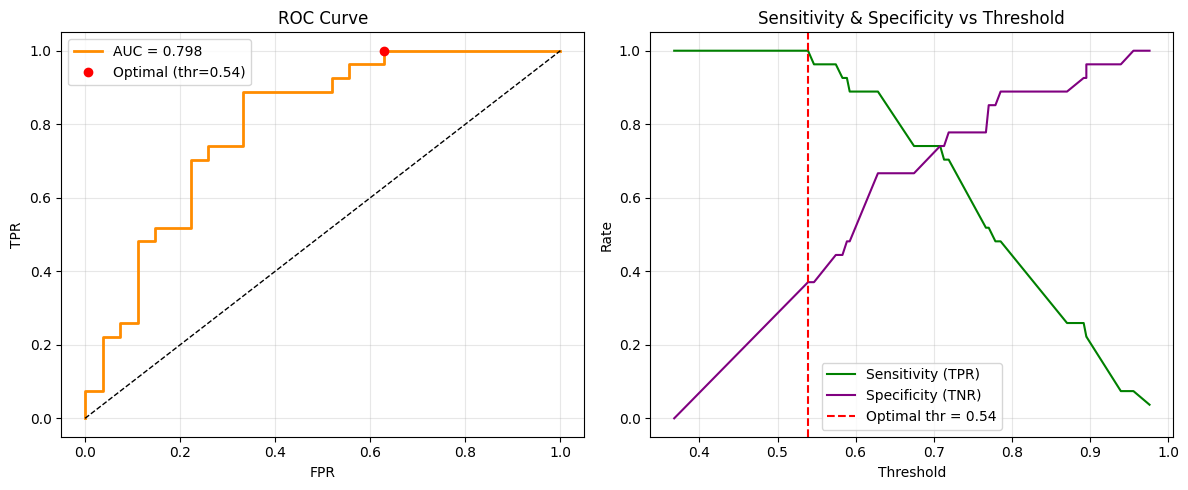

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ROC Curve
axs[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axs[0].plot(opt_fpr, opt_tpr, 'ro', label=f'Optimal (thr={opt_threshold:.2f})')
axs[0].plot([0,1], [0,1], 'k--', lw=1)
axs[0].set_xlabel('FPR')
axs[0].set_ylabel('TPR')
axs[0].set_title('ROC Curve')
axs[0].legend()
axs[0].grid(alpha=0.3)

# Threshold plot
axs[1].plot(thresholds, tpr, label='Sensitivity (TPR)', color='green')
axs[1].plot(thresholds, 1 - fpr, label='Specificity (TNR)', color='purple')
axs[1].axvline(opt_threshold, color='red', linestyle='--', label=f'Optimal thr = {opt_threshold:.2f}')
axs[1].set_xlabel('Threshold')
axs[1].set_ylabel('Rate')
axs[1].set_title('Sensitivity & Specificity vs Threshold')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
ncells_to_plot = []
nsubs_to_plot = []
f1_score_to_plot = []
recall_score_to_plot = []

tested_ncells, tested_nsubs = [], []
heatmap_dict = {}
for (ncells, nsubs), fold in zip(tested_par, val_predicted_for_roc):
    f1_fold, rec_fold = [], []
    for pred_list, val_y in fold:
        pred_phenotype_df, accuracy_list, f1_score_list, recall_score_list = elaborate_predictions(
                                pred_list, val_y, results=False
                            )
        f1_fold.append(f1_score_list)
        rec_fold.append(recall_score_list)
        
    print(f'(ncells, nsubs): {(ncells, nsubs)}, f1  scores: {np.mean(f1_fold)}')
    print(f'(ncells, nsubs): {(ncells, nsubs)}, rec scores: {np.mean(rec_fold)}')
    #print(f'(ncells, nsubs): {(ncells, nsubs)}, f1  scores: {f1_fold}')
    #print(f'(ncells, nsubs): {(ncells, nsubs)}, rec scores: {rec_fold}')
    #print(ncells, nsubs)
    print('')
    ncells_to_plot.append(ncells)
    nsubs_to_plot.append(nsubs)
    f1_score_to_plot.append(np.mean(f1_fold))
    recall_score_to_plot.append(np.mean(rec_fold))

    tested_ncells.append(ncells)
    tested_nsubs.append(nsubs)
    
heatmap_dict['ncells'] = tested_ncells
heatmap_dict['nsubs'] = tested_nsubs
heatmap_dict['f1'] = f1_score_to_plot
heatmap_dict['recall'] = recall_score_to_plot


(ncells, nsubs): (500, 50), f1  scores: 0.76
(ncells, nsubs): (500, 50), rec scores: 1.0

(ncells, nsubs): (500, 550), f1  scores: 0.76
(ncells, nsubs): (500, 550), rec scores: 1.0

(ncells, nsubs): (700, 550), f1  scores: 0.7766666666666666
(ncells, nsubs): (700, 550), rec scores: 1.0

(ncells, nsubs): (100, 200), f1  scores: 0.6128205128205128
(ncells, nsubs): (100, 200), rec scores: 0.6333333333333333

(ncells, nsubs): (600, 600), f1  scores: 0.7695238095238095
(ncells, nsubs): (600, 600), rec scores: 0.9666666666666668

(ncells, nsubs): (500, 550), f1  scores: 0.76
(ncells, nsubs): (500, 550), rec scores: 1.0

(ncells, nsubs): (100, 600), f1  scores: 0.623076923076923
(ncells, nsubs): (100, 600), rec scores: 0.6

(ncells, nsubs): (400, 450), f1  scores: 0.7452813852813852
(ncells, nsubs): (400, 450), rec scores: 0.8

(ncells, nsubs): (100, 500), f1  scores: 0.623076923076923
(ncells, nsubs): (100, 500), rec scores: 0.6

(ncells, nsubs): (700, 450), f1  scores: 0.7695238095238095
(n

In [24]:
print(heatmap_dict['recall'])
print(heatmap_dict['f1'])

print(len(heatmap_dict['nsubs']))
print(len(heatmap_dict['ncells']))


[1.0, 1.0, 1.0, 0.6333333333333333, 0.9666666666666668, 1.0, 0.6, 0.8, 0.6, 0.9666666666666668]
[0.76, 0.76, 0.7766666666666666, 0.6128205128205128, 0.7695238095238095, 0.76, 0.623076923076923, 0.7452813852813852, 0.623076923076923, 0.7695238095238095]
10
10


In [25]:
heatmap_dict['nsubs']

[50, 550, 550, 200, 600, 550, 600, 450, 500, 450]

In [26]:
heatmap_dict['ncells']

[500, 500, 700, 100, 600, 500, 100, 400, 100, 700]

In [27]:
best_f1 = heatmap_dict['f1'][best_idx]
best_rec = heatmap_dict['recall'][best_idx]

print(best_f1, best_rec)

0.7766666666666666 1.0


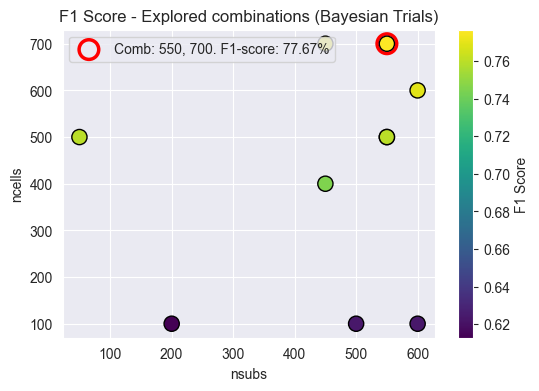

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.DataFrame(heatmap_dict)
sns.set_style("darkgrid")  # oppure "whitegrid", "ticks"

plt.figure(figsize=(6, 4))
best_ncells, best_nsub

best_f1 = df['f1'].iloc[best_idx]

plt.scatter(best_nsub, best_ncells,    
            s=200,        
            facecolors='none', 
            edgecolors='red',         # ← bordo rosso
            linewidth=2.5,
            label=f'Comb: {best_nsub}, {best_ncells}. F1-score: {best_f1*100:.2f}%'
                     )
scatter = plt.scatter(df['nsubs'], df['ncells'], c=df['f1'], cmap='viridis',    
            s=120,                 # dimensione dei punti
            edgecolor='black',     # 👈 contorno nero
            linewidth=1            # 👈 spessore del contorno)
                     )

plt.colorbar(scatter, label='F1 Score')
plt.ylabel('ncells')
plt.xlabel('nsubs')
plt.title('F1 Score - Explored combinations (Bayesian Trials)')
plt.legend( fontsize = 10)

plt.show()

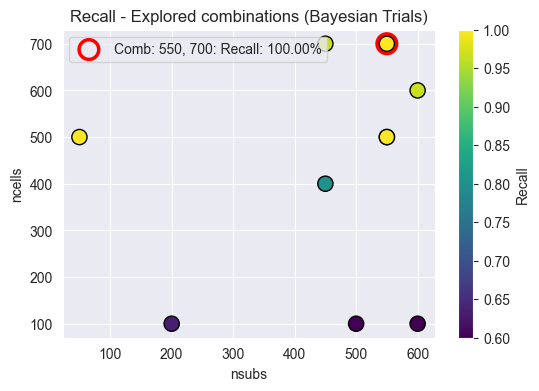

In [29]:
import matplotlib.pyplot as plt
df = pd.DataFrame(heatmap_dict)
sns.set_style("darkgrid")  # oppure "whitegrid", "ticks"
plt.figure(figsize=(6, 4))

best_rec = df['recall'].iloc[best_idx]
plt.scatter(best_nsub, best_ncells,    
            s=200,        
            facecolors='none', 
            edgecolors='red',         # ← bordo rosso
            linewidth=2.5,
            label=f'Comb: {best_nsub}, {best_ncells}: Recall: {best_rec*100:.2f}%'
                     )

scatter = plt.scatter(df['nsubs'], df['ncells'],  c=df['recall'], cmap='viridis', 
            s=120,                 # dimensione dei punti
            edgecolor='black',     # 👈 contorno nero
            linewidth=1            # 👈 spessore del contorno)
                     )
plt.colorbar(scatter, label='Recall')
plt.ylabel('ncells')
plt.xlabel('nsubs')
plt.title('Recall - Explored combinations (Bayesian Trials)')
plt.legend( fontsize = 10)
plt.show()

In [32]:
    import pickle
    save_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Final_model/experiment_{exp}/fold_{fold_idx}/results/direct'
    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(save_dir, 'original_predictions_list.pkl'), 'rb') as f:
                    original_predictions_list = pickle.load(f)
        
    with open(os.path.join(save_dir, 'original_results_list.pkl'), 'rb') as f:
                    original_results_list = pickle.load(f)


In [33]:
    save_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Final_model/experiment_{exp}/fold_{fold_idx}/results/robust'
    os.makedirs(save_dir, exist_ok=True)
    with open(os.path.join(save_dir, 'test_total_labels.pkl'), 'rb') as f:
                    test_total_labels = pickle.load(f)
        
    with open(os.path.join(save_dir, 'test_total_pred_lists.pkl'), 'rb') as f:
                    test_total_pred_lists = pickle.load(f)
        
    with open(os.path.join(save_dir, 'test_total_trial_pred_lists.pkl'), 'rb') as f:
                    test_total_trial_pred_lists = pickle.load(f)
        
    with open(os.path.join(save_dir, 'per_donor_resampled_test_y.pkl'), 'rb') as f:
                    per_donor_resampled_test_y = pickle.load(f)

    with open(os.path.join(save_dir, 'per_donor_original_test_datasets.pkl'), 'rb') as f:
                    per_donor_original_test_datasets = pickle.load(f)
        
    with open(os.path.join(save_dir, 'per_donor_original_test_y.pkl'), 'rb') as f:
                    per_donor_original_test_y = pickle.load(f)

In [34]:
original_test_datasets, original_test_y = flatten(per_donor_original_test_datasets), flatten(per_donor_original_test_y)

In [35]:
from sklearn.metrics import f1_score

def final_trials_prediction(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y, best_threshold):
    from sklearn.metrics import f1_score
    """ Elaborate data to show distribution of trial results over the entire set of timepoints and patiets"""
    prob_data = []
    f1_data = []
    boxplot_data = []
    
    for patient, patient_ys, patient_resampled_y in zip(total_trial_pred_lists, per_donor_original_test_y, per_donor_resampled_test_y):

        for timepoint, true_timepoint_y, true_resampled_y in zip(patient, patient_ys, patient_resampled_y):
            label_str = "Positive" if true_timepoint_y == 1 else "Negative"
            
            timepoint_boxplot_data = []
            timepoint_f1_data = []
            #print(timepoint)
            for trial in timepoint: # from each timepoint multiple samples has been generated. each sample has been predicted 10 times using the same 'best' model but using a different seed each time
                             # each sub is a pediction of the 20 samples of a single timepoint

                #print(trial)
                trial_prob = np.mean(trial) # mean of the probabilities of the subsets
                
                trial_pred = (np.array(trial) >= best_threshold*0.01).astype(int)
                #print(trial_pred)
                #print(true_resampled_y)
                
                trial_f1 =  f1_score(true_resampled_y, trial_pred, pos_label = 1, zero_division=1)
                #print(rqver)
                
                prob_data.append({
                "True_Label": label_str,
                "Timepoint_Score": trial_prob
                })
                
                
                timepoint_boxplot_data.append(trial_prob)
                timepoint_f1_data.append(trial_f1)
                
            boxplot_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_boxplot_data
                })
            
            f1_data.append({
                "True_Label": true_timepoint_y,
                "Timepoint_trials_scores": timepoint_f1_data
                })
                
    return prob_data, boxplot_data, f1_data
    
    
print(f'Predicted  Labels: {test_total_labels}')

print(f'Timepoints Labels: {per_donor_original_test_y}')

plot_data, boxplot_data, f1_data = final_trials_prediction(test_total_trial_pred_lists, 
                                                           per_donor_original_test_y, per_donor_resampled_test_y, threshold)

Predicted  Labels: [[1, 1, 1]]
Timepoints Labels: [[1, 1, 0]]


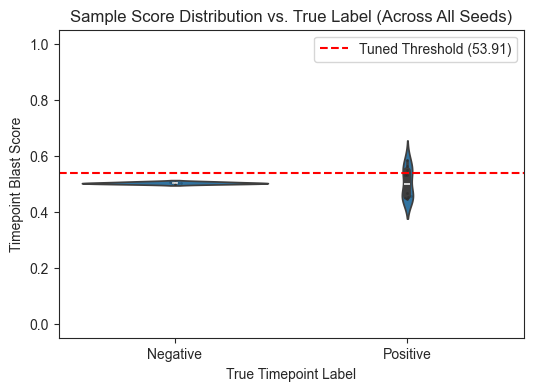

In [36]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("ticks")

# Convert your data into a DataFrame
df = pd.DataFrame(plot_data)

# --- Create the plot ---
plt.figure(figsize=(6, 4))

# A Violin plot is like a boxplot but shows the full distribution
sns.violinplot(
    x="True_Label", 
    y="Timepoint_Score", 
    data=df,
    order=["Negative", "Positive"] # Ensure this order
)

# You can also add a swarmplot to see the individual points
sns.swarmplot(
    x="True_Label",
    y="Timepoint_Score",
    data=df,
    color="black",
    alpha=0.2, # Make points transparent
    size=2,
    order=["Negative", "Positive"]
)

# --- Add your threshold line! ---
# This is the line that separates your predictions
TUNED_THRESHOLD = threshold # The threshold you found in your tuning
plt.axhline(y=TUNED_THRESHOLD*0.01, color='red', linestyle='--', label=f'Tuned Threshold ({TUNED_THRESHOLD:.2f})')
plt.ylim(-0.05, 1.05) # (Set the y-axis limit, 1.05 gives a little space)
plt.title('Sample Score Distribution vs. True Label (Across All Seeds)')
plt.ylabel('Timepoint Blast Score')
plt.xlabel('True Timepoint Label')
plt.legend()
plt.show()


C:\Users\Enrico Didoli\AppData\Local\Temp\ipykernel_13436\2816273836.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(timepoints_trials_scores, labels=timepoints_labels)


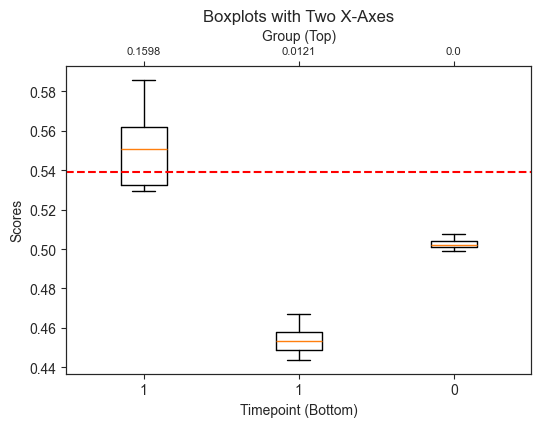

In [37]:
#print(boxplot_data)
sns.set_style("ticks")
timepoints_blast_perc = []
for donor in per_donor_original_test_datasets:
        for i, dataset in enumerate(donor):
            blast_n = (dataset['IsBlast'] == 1).sum()/len(dataset)
            timepoints_blast_perc.append(round(blast_n*100,4))
            
timepoints_labels = [timepoint["True_Label"] for i, timepoint in enumerate(boxplot_data)]
timepoints_trials_scores = [timepoint["Timepoint_trials_scores"] for timepoint in boxplot_data]
#print(timepoints_labels)
#print(timepoints_trials_scores)

# --- Your Solution (One Line) ---
# Create a figure and axes
fig, ax1 = plt.subplots(figsize=(6, 4))

# 2. Plot the boxplot on the first axes (ax1)
ax1.boxplot(timepoints_trials_scores, labels=timepoints_labels)
ax1.set_xlabel("Timepoint (Bottom)")
ax1.set_ylabel("Scores")

# 3. Create the SECOND axes (ax2)
ax2 = ax1.twiny()

# 4. Configure the second axes
# Make ax2 have the same limits and ticks as ax1
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(ax1.get_xticks()) # Positions [1, 2, 3, 4]

# Set the new labels for the top axis
ax2.set_xticklabels(timepoints_blast_perc, fontsize=8)
ax2.set_xlabel("Group (Top)")
plt.axhline(y=TUNED_THRESHOLD*0.01, color='red', linestyle='--', label=f'Tuned Threshold ({TUNED_THRESHOLD})')

plt.title("Boxplots with Two X-Axes")
plt.show()

In [38]:
from sklearn.metrics import f1_score, accuracy_score, recall_score
from results_elaboration import elaborate_predictions

def elaborate_direct_prediction(imported_predictions, imported_test_y, metric = 'acc'):

    if metric == 'acc':
        pos = 0
    elif metric == 'f1':
        pos = 1
    elif metric == 'rec':
        pos = 2

    labels_flat = flatten(imported_test_y)
    # elaborate metric data from imported predictions
    models_metric_lists = []
    metrics = elaborate_metrics(imported_predictions, labels_flat)

    return metrics[pos] # extract the metric in the chosen position

def elaborate_metrics(imported_predictions, imported_test_y, results = False):
    #print(imported_predictions)
    new_pred_phenotype_df, new_accuracy_list, new_f1_score_list, new_recall_score_list = elaborate_predictions(imported_predictions, imported_test_y, results = results)
    return new_accuracy_list, new_f1_score_list, new_recall_score_list

def direct_model_comparison_barplot(direct, metric_name, subtitle = False):
    
    models_values = list(direct.values())
    models_names = [name.replace('model_', '') for name in direct.keys()]
    
    errors = []
    means = []
    for val in models_values:
        m = np.mean(val)
        means.append(m)
        s = np.std(val)
        errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    
    bars = ax.bar(models_names, means, yerr= errors, color=colors, edgecolor='black', capsize=5)
    
    for bar, mean, error in zip(bars, means, errors):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{mean:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'Direct Prediction {metric_name} per method', fontsize=14, fontweight='bold')
    plt.suptitle(f'Scores (Direct Prediction)', fontsize=14, fontweight='bold')
    
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
        
    ax.set_ylabel(metric_name, fontsize=12)
    high_limit = np.max(np.array(means) + np.array(errors))
    
    ax.set_ylim(0, max(1, high_limit + 0.05)) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.xticks(rotation=60)
    plt.tight_layout()
    
    plt.show()


2


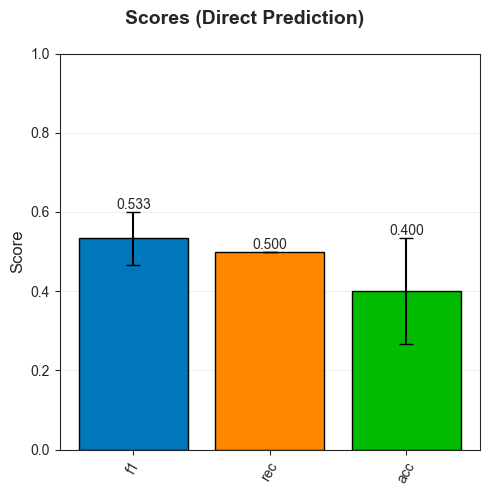

In [39]:
# mwtrics across folds

trials_mean_predictions = []
for i , trial in enumerate(original_predictions_list): 
    # trial
    trials_mean = np.mean(trial, axis = 0).tolist() # mean across trials inside the fold
    trials_mean_predictions.append(trials_mean)
print(len(trials_mean))

direct_metrics_across_trials= {}



dir_f1 = elaborate_direct_prediction(original_predictions_list, per_donor_original_test_y, 'f1')
dir_rec = elaborate_direct_prediction(original_predictions_list, per_donor_original_test_y, 'rec')
dir_acc = elaborate_direct_prediction(original_predictions_list, per_donor_original_test_y, 'acc')


mod_n = 'f1'
direct_metrics_across_trials[mod_n] = dir_f1
mod_n = 'rec'
direct_metrics_across_trials[mod_n] = dir_rec
mod_n = 'acc'
direct_metrics_across_trials[mod_n] = dir_acc

direct_model_comparison_barplot(direct_metrics_across_trials, 'Score')#, subtitle)

In [40]:
def elaborate_robust_prediction(trials_pred_lists, imported_test_y, threshold):
    # group the files in a single vector
    per_files_preds = []
    for patient in trials_pred_lists:
        per_files_preds += patient
    
    # group the files labels in a single vector
    true_labels_flat = flatten(imported_test_y)
    
    files_trial_scores = []
    for i, file in enumerate(per_files_preds):
        trial_scores = []
        for trial in file:
            trial_scores.append(np.mean(trial)) # mean positive score per trial
        files_trial_scores.append(trial_scores) # for every file, a vector of |trials| each representing a file
        
    f1_model, recall_model, acc_model = [], [], []
    
    model_pred_df = pd.DataFrame(files_trial_scores).T # transpose to work on trial-level
    #print(model_pred_df)
    for trial in model_pred_df.values:
        trial_prediction = (np.array(trial) >= threshold*0.01).astype(int) # for each trial predict labels

        
        f1 = f1_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=0) # and check f1_score
        f1_model.append(f1)

        rec = recall_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=0) # and check recall
        recall_model.append(rec)

        acc = accuracy_score(true_labels_flat, trial_prediction) # and check accuracy
        acc_model.append(acc)

    return f1_model, recall_model, acc_model #list of f1_score extracted from each trial

def robust_model_comparison_barplot(all_tested_models, metric, subtitle = False):
    if metric == 'f1':
        pos = 0
        metric_name = 'F1-score'
    elif metric == 'rec':
        pos = 1
        metric_name = 'Recall'
    elif metric == 'acc':
        pos = 2
        metric_name = 'Accuracy'
        
    models_metric = [model[pos] for model, _ in list(all_tested_models.values())]
    models_names = [name.replace('model_', '') for name in list(all_tested_models.keys())]

    final_predictions = [flatten(final_pred[0]) for _, final_pred in list(all_tested_models.values())]
    true_labels = [flatten(final_pred[1]) for _, final_pred in list(all_tested_models.values())]
    
    for labels in true_labels:
        if true_labels[0] != labels:
            print(f'Warnining: the model analyzed have been tested on different test sets.')
            print(f'Double check the models you are analysing!')
        

    final_f1_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=0) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    final_f1_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=0) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    
    # add the text above the bars
    if metric == 'f1':
        final_pred_score = [f1_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    if metric == 'rec':
        final_pred_score = [recall_score(true_lab, pred, pos_label = 1, zero_division=1) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
    if metric == 'acc':
        final_pred_score = [accuracy_score(true_lab, pred) for true_lab, pred in zip(true_labels, final_predictions)] # and check f1_score
         
    
    f1_errors = []
    f1_means = []
    for f1 in models_metric:
        m = np.mean(f1)
        f1_means.append(m)
        s = np.std(f1)
        f1_errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(5, 5))
    #bars = ax.bar(models_names, f1_means, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)
    bars = ax.bar(models_names, final_pred_score, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)

    for bar, mean, error, final_score in zip(bars, f1_means, f1_errors, final_pred_score):
        height = bar.get_height()
        
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{final_score:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    plt.suptitle(f'{metric_name} per model (Robust Approach)', fontsize=14, fontweight='bold')
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
    
    ax.set_ylabel(metric_name, fontsize=12)

    # set the limits for a better visualization
    max_mean = np.max(np.array(f1_means) + np.array(f1_errors))
    max_preds = np.max(np.array(final_pred_score) + np.array(f1_errors))
    print(max_mean, max_preds)
    high_limit = max(max_mean, max_preds) # sum each element in f1_means to its elative in errors. than thake the max of the vector
    
    ax.set_ylim(0, max(1, high_limit + 0.05) ) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()

    
def robust_prediction_labelling(trials_pred_lists, threshold):
    patient_timepoints_labels = []
    for patient in trials_pred_lists:
        file_labels = []
        for file in patient:
            positive_probs_mean = np.mean(file , axis=0) #column mean
            mean_timepoint_probs = np.mean(positive_probs_mean) #row mean to get the positive scores
         
            if mean_timepoint_probs >= threshold*0.01:
                file_labels.append(1)
            else:
                file_labels.append(0)
        patient_timepoints_labels.append(file_labels)
    return patient_timepoints_labels 
#print(patient_timepoints_labels)

0.7265986323710905 0.7265986323710905
0.5449489742783178 0.5449489742783178
0.6966326495188785 0.6966326495188785


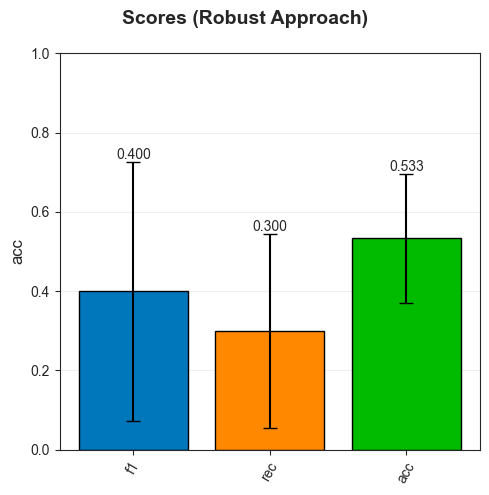

In [42]:
trials_mean_predictions = []
for trial in range(len(test_total_trial_pred_lists[0][0])):
    trial_files_mean = []
    for i, patient in enumerate(test_total_trial_pred_lists):
        for file in patient:
            #print(len(file[trial]))
            trial_files_mean.append(np.mean(file[trial]))
    #print(trial_files_mean)
            
    trials_mean_predictions.append(trial_files_mean)
    
    
    
rob_f1, rob_rec, rob_acc = [], [], []
true_labels_flat = flatten(per_donor_original_test_y)
for trial in trials_mean_predictions:
        trial_prediction = (np.array(trial) >= threshold*0.01).astype(int) # for each trial predict labels

        
        f1 = f1_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=0) # and check f1_score
        rob_f1.append(f1)

        rec = recall_score(true_labels_flat, trial_prediction, pos_label = 1, zero_division=0) # and check recall
        rob_rec.append(rec)

        acc = accuracy_score(true_labels_flat, trial_prediction) # and check accuracy
        rob_acc.append(acc)
    
mod_n = ['f1', 'rec', 'acc']
metric_names = ['f1', 'rec', 'acc']
subtitle = None
# Create bar plot
fig, ax = plt.subplots(figsize=(5, 5))
for i, metric_name in enumerate(metric_names): 

    
    f1_errors = []
    f1_means = []
    if metric_name == 'f1':
        f1 = rob_f1
    elif metric_name == 'rec':
        f1 = rob_rec
    elif metric_name == 'acc':
        f1 = rob_acc
    
    m = np.mean(f1)
    f1_means.append(m)
    s = np.std(f1)
    f1_errors.append(s)
    
    # Colors matching the plot
    colors = ['#0077BB', '#FF8800', '#00BB00', '#DD0000', '#AA55BB']
    
    
    #bars = ax.bar(models_names, f1_means, yerr=f1_errors, color=colors, edgecolor='black', capsize=5)
    bars = ax.bar(mod_n[i],f1_means, yerr=f1_errors, color=colors[i], edgecolor='black', capsize=5)

    for bar, mean, error, final_score in zip(bars, f1_means, f1_errors, f1_means):
        height = bar.get_height()
        
        ax.text(bar.get_x() + bar.get_width()/2., height + error,
                f'{final_score:.3f}',
                ha='center', va='bottom', fontsize=10)
        
    # Customize
    #plt.suptitle(f'{metric_name} per model (Robust Approach)', fontsize=14, fontweight='bold')
    plt.suptitle(f'Scores (Robust Approach)', fontsize=14, fontweight='bold')
    
    if subtitle:
        ax.set_title(f'{subtitle}', fontsize=11)
    
    ax.set_ylabel(metric_name, fontsize=12)

    # set the limits for a better visualization
    max_mean = np.max(np.array(f1_means) + np.array(f1_errors))
    max_preds = np.max(np.array(f1_means) + np.array(f1_errors))
    print(max_mean, max_preds)
    high_limit = max(max_mean, max_preds) # sum each element in f1_means to its elative in errors. than thake the max of the vector
    
    ax.set_ylim(0, max(1, high_limit + 0.05) ) # Adjust based on your data range
    ax.grid(True, alpha=0.3, axis='y')

    plt.xticks(rotation=60)
    plt.tight_layout()
plt.show()




In [56]:
for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(Ensemble_LOPOCV_patients_folds): # for each LOPO fold
    print(test_pat)
    test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)
    original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
    print(multiple_donations)
    print(original_test_y)
    if LOPOCV_fold_idx == 0:
        break

['11']
{'11': [0, 1, 2], '12': [3, 4], '1': [5, 6], '2': [7, 8], '3': [9, 10], '4': [11, 12, 13], '6': [14, 15], '7': [16, 17, 18], '8': [19, 20], '9': [21, 22]}
[1, 1, 0]


In [59]:
marker_names = list(test_datasets_extracted[0][0].columns)[:-1]
print(marker_names)

['FSC-A', 'FSC-H', 'SSC-A', 'CD81(FITC-A)', 'CD73+CD304(PE-A)', 'CD34(PerCP-Cy5-5-A)', 'CD19(PE-Cy7-A)', 'CD10(APC-A)', 'CD38(APC-C750-A)', 'CD20(PB-A)', 'CD45(OC515-A)']


In [84]:
decache_files = ['timepoints_elaboration', 'results_elaboration', 'new_datasets_generation', 'run_models',
                 'old_cellCnn.model', 'old_cellCnn.utils', 'old_cellCnn.downsample', 'old_cellCnn.model_grid',
                'All_fixed_functions', 'old_cellCnn.plotting']

# Rimuovi il modulo specifico dalla cache
from timepoints_elaboration import remove_from_cache
remove_from_cache(decache_files)


# import downloaded modules
from old_cellCnn.model import CellCnn

import old_cellCnn.utils as utils
import old_cellCnn.downsample as downsample
from old_cellCnn.plotting import plot_results, plot_filters, discriminative_filters
from old_cellCnn.utils import mkdir_p, get_selected_cells

from timepoints_elaboration import load_data, donation_extraction, dataset_elaboration
from timepoints_elaboration import donor_division, patient_code_extraction, remove_from_cache

from results_elaboration import extract_hyper, phenotype_prediction, default_serializer, show_hyperparameters
from results_elaboration import elaborate_predictions, show_hyper

from run_models import trials_train_CellCNN, trials_test_CellCNN, trials_train_CellCNN_old, trials_test_CellCNN_old

from new_datasets_generation import splitting_and_dataset_elaboration



timepoints_elaboration rimosso dalla cache
results_elaboration rimosso dalla cache
new_datasets_generation rimosso dalla cache
run_models rimosso dalla cache
old_cellCnn.model rimosso dalla cache
old_cellCnn.utils rimosso dalla cache
old_cellCnn.downsample rimosso dalla cache
old_cellCnn.model_grid non trovato nella cache
All_fixed_functions non trovato nella cache
old_cellCnn.plotting rimosso dalla cache


In [70]:
def load_models(model, meta):
        '''
        model.scale = metadata.all_params['scale']
        model.quant_normed = metadata.all_params['quant_normed'] 
        model.regression = metadata.all_params['regression'] 
        model.nsubset = metadata.all_params['nsubset'] 
        model.ncell = metadata.all_params['ncell']
        model.per_sample = metadata.all_params['per_sample'] 
        model.subset_selection = metadata.all_params['subset_selection'] 
        model.maxpool_percentages = metadata.all_params['maxpool_percentages'] 
        model.nfilter_choice = metadata.all_params['nfilter_choice']
        model.learning_rate = metadata.all_params['learning_rate'] 
        model.coeff_l1 = metadata.all_params['coeff_l1'] 
        model.coeff_l2 = metadata.all_params['coeff_l2'] 
        model.dropout = metadata.all_params['dropout'] 
        model.dropout_p = metadata.all_params['dropout_p'] 
        model.max_epochs = metadata.all_params['max_epochs'] 
        model.patience = metadata.all_params['patience']
        model.dendrogram_cutoff = metadata.all_params['dendrogram_cutoff'] 
        model.accur_thres = metadata.all_params['accur_thres'] 
        model.verbose = metadata.all_params['verbose']
        model.resampled = metadata.all_params['resampled'] 
        model.seed = metadata.all_params['seed'] 
        model.results = metadata.all_params['results']
    
        '''            
        model = CellCnn()

        model.scale = meta['scale']
        model.quant_normed = meta['quant_normed'] 
        model.regression = meta['regression'] 
        model.nsubset = meta['nsubset'] 
        model.ncell = meta['ncell']
        model.per_sample = meta['per_sample'] 
        model.subset_selection = meta['subset_selection'] 
        model.maxpool_percentages = meta['maxpool_percentages'] 
        model.nfilter_choice = meta['nfilter_choice']
        model.learning_rate = meta['learning_rate'] 
        model.coeff_l1 = meta['coeff_l1'] 
        model.coeff_l2 = meta['coeff_l2'] 
        model.dropout = meta['dropout'] 
        model.dropout_p = meta['dropout_p'] 
        model.max_epochs = meta['max_epochs'] 
        model.patience = meta['patience']
        model.dendrogram_cutoff = meta['dendrogram_cutoff'] 
        model.accur_thres = meta['accur_thres'] 
        model.verbose = meta['verbose']
        model.resampled = meta['resampled'] 
        model.seed = meta['seed'] 
        model.results = meta['results']
    
        
        return model

In [74]:
%%time
import pickle
import os
exp = 1
# Assicurati di avere la tua funzione per costruire il modello
# from tuo_file import build_cellcnn_model 


counter_tuning_seed = 0
counter_robust_testing_seed = 0
thr_tuning_seed_list = generate_seeds(len(Ensemble_LOPOCV_patients_folds)*2, seed = int(starting_seed))[:len(Ensemble_LOPOCV_patients_folds)]
robust_approach_seed_list = generate_seeds(len(Ensemble_LOPOCV_patients_folds)*2, seed = int(starting_seed))[len(Ensemble_LOPOCV_patients_folds):]

time_per_fold = []


for fold_idx, (kfolds, patient) in enumerate(Ensemble_LOPOCV_patients_folds):
    
    train_donors_idx = np.concatenate(kfolds[0])
    val_donors_idx = patient
    
    train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
    val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
    test_datasets_extracted =  donation_extraction(patient, multiple_donations, ALL_DATASETS)

    
    original_train_datasets, original_train_y = retrieve_labels(train_datasets_extracted, remove = True, flat = True)
    original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
    
    #test_datasets_extracted = create_file_with_small_perc(test_datasets_extracted)
    train, test = train_val_finalizing(original_train_datasets, original_test_datasets, grid, labels)
    if fold_idx == 0:
        break
    trials = 5
    print(f'\nFold: {LOPOCV_fold_idx}\n')

    seed_list = generate_seeds(len(Ensemble_LOPOCV_patients_folds)*2, seed = int(starting_seed/5) + len(Ensemble_LOPOCV_patients_folds) + LOPOCV_fold_idx)
    prediction_seed_list = generate_seeds(trials, seed = int(starting_seed/2) + trials + LOPOCV_fold_idx)

    best_ncells = best_ncells
    best_nsub =  best_nsub
    print(f'Tuned ncells value: {best_ncells}')
    print(f'Tuned nsub value: {best_nsub}')
    
    grid = True #grid search
    labels = False # the  subsets sampled by the model do not maintain original blast distribution
    CellCnn = grid_or_rand_model(grid) # loads the correct model module
              
    load_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Final_model/experiment_{exp}/fold_{LOPOCV_fold_idx}/training/models'
   
    all_trials = os.listdir(load_dir)
    print(f'all_trials: {all_trials}')

    loaded_models_lists = []
    for i, trial in enumerate(all_trials):
      #if i in [0,1]:
        print(trial)
        model = []
        model_dir = f'{load_dir}/seed_{i}'

                
        # A. Carica Config e Metadata
        print('Before uploading meta')
        with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
            meta = pickle.load(f)
            
        print(type(meta))
        if isinstance(meta, dict):
            print("Keys:", list(meta.keys()))
        elif hasattr(meta, 'all_params'):
            print("Keys in all_params:", list(meta.all_params.keys()))
        print('Meta uploaded!!!')
        print('')
        print('')
        print('')
        print('')
        print('')
            
        model = load_models(model, meta)
        #model.results = meta
        loaded_models_lists.append(model)
        if LOPOCV_fold_idx == 0:
            break

20
3
_abels from Train and Validations Sets have been REMOVED.
Grid Search Ready!
CPU times: total: 1.53 s
Wall time: 1.56 s


In [77]:
print(loaded_models_lists[0].results)

{'scaler': StandardScaler(), 'n_classes': 2, 'model_sorted_idx': array([23, 22,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21,  0], dtype=int64), 'config': {'nfilter': [5, 5, 5, 5, 5, 5, 5, 5, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 9, 9, 9, 9, 9], 'learning_rate': [0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005, 0.001, 0.005], 'maxpool_percentage': [0.01, 0.01, 1, 1, 10, 10, 100, 100, 0.01, 0.01, 1, 1, 10, 10, 100, 100, 0.01, 0.01, 1, 1, 10, 10, 100, 100]}, 'accuracies': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0.]), 'best_3_nets': [[array([[[ 5.7494090e-33, -2.1188238e-01, -2.2152792e-01, -2.2609161e-01,
         -2.4275307e-01, -5.4654253e-01, -2.1913464e-01,  5.6241255e-33,
         -1.7547499e-01],
        [-6.8633508e-33, -3.4029907e-01, -3.0802834e-01, -3.2263216e-01,
      

In [85]:

%%time
config_save_dir = f'{cellcnn_path}/New running ipynb/Fixed/5.LOOCV_final_run/Final_model/experiment_{exp}/fold_{fold_idx}/plots'
filter_diff_thres = 0.2
filter_response_thres = 0
stat_test = None
group_a = 'group A'
group_b = 'group B'
group_names = None
tsne_ncell = 1000
regression = False

if True:
        
        # if args.plot or args.export_selected_cells:
        plotdir = os.path.join(config_save_dir, 'plots')
        plot_filters(loaded_models_lists[0].results, marker_names, os.path.join(plotdir, 'filter_plots'))
        _v = discriminative_filters(loaded_models_lists[0].results, os.path.join(plotdir, 'filter_plots'),
                                    filter_diff_thres=filter_diff_thres,
                                    show_filters=True)
        
        filter_info = plot_results(loaded_models_lists[0].results, train, original_train_y,
                                   marker_names, os.path.join(plotdir, 'training_plots'),
                                   filter_diff_thres= filter_diff_thres,
                                   filter_response_thres= filter_response_thres,
                                   stat_test=stat_test,
                                   group_a=group_a, group_b=group_b,
                                   group_names=group_names,
                                   tsne_ncell=tsne_ncell,
                                   regression=regression,
                                   show_filters=False)

        print('ready to plot')
        _v = plot_results(loaded_models_lists[0].results, test, original_test_y,
                          marker_names, os.path.join(plotdir, 'validation_plots'),
                          filter_diff_thres=filter_diff_thres,
                          filter_response_thres=filter_response_thres,
                          stat_test=stat_test,
                          group_a=group_a, group_b=group_b,
                          group_names=group_names,
                          tsne_ncell=tsne_ncell,
                          regression=regression,
                          show_filters=False)
        '''
        if True:
            csv_dir = os.path.join(config_save_dir, 'selected_cells')
            mkdir_p(csv_dir)
            nfilter = len(filter_info)
            #sample_names = [name.split('.fcs')[0] for name in list(fcs_info[:, 0])]
            sample_names = [str(num) for num in list(range(len(original_test_datasets)))]
            # for each sample
            for x, x_name in zip(original_test_datasets, sample_names):
                flags = np.zeros((x.shape[0], 2*nfilter))
                columns = []
                # for each filter
                for i, (filter_idx, thres) in enumerate(filter_info):
                    flags[:, 2*i:2*(i+1)] = get_selected_cells(
                                                            loaded_models_lists[0].results['selected_filters'][filter_idx],
                                                            x, loaded_models_lists[0].results['scaler'],
                                                            thres, True)
                    
                    columns += ['filter_%d_continuous' % filter_idx, 'filter_%d_binary' % filter_idx]
                df = pd.DataFrame(flags, columns=columns)
                df.to_csv(os.path.join(csv_dir, x_name+'_selected_cells.csv'), index=False)
        
        '''

(25924132, 11)
x shape: 25924132
ciao

scaler not present False
Computing t-SNE projection...
(25924132, 11)
x_for_tsne: [20112921 22189265 18121307 17181686  4329394   791624  7079903 21866106
  1601207 22025925 19772251 10697913 22980906 17261643 10806322 14377746
 13107348 20736121 13180114  4083372 17886445 20670839 12775505  6191081
 18867100 20981315 14220331  8309740  9900154 24051036  4821699  6605129
  6172056  1496030 11237698 16788225 21149688 18500696  8313264 20476613
 15069977  1991367 22346850 15796762  8718936 21186229 19485884 21830895
  1000294 16333698 11587062 22435523 24951460  2285362 19620110 11838983
  8565873  7860791 13430702 11615193 11916937 19813989 13890893  4384432
 18468008 18408786 16716573 11879286  4773598  1660102 10733778  1511710
 24053497 13708759 17593825 21361686  6807087  4062316  5587239 11577349
  1655464  9795427  8377114 13947082 25133380 16169784   878835 15118662
 25789402  7556142  3277560 19947086 10858093  5088268  7279995 23200108
 19

C:\Anaconda37\envs\jupyter_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Anaconda37\envs\jupyter_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


i_filter: 1
DEBUG ncol: [[ 0.37946448  0.14048067  0.5061912  ... -0.03553333 -0.08008386
   0.01404285]
 [ 1.4587988   1.0439631   0.7103894  ...  0.11409564 -0.28879154
   0.12261388]
 [-1.0590124  -1.1784163  -0.30012625 ... -1.0408528  -0.7519427
  -2.1939542 ]
 ...
 [-0.13616279 -0.5988259   0.09981818 ...  1.2538241  -0.02037289
   0.31319618]
 [ 1.7785997   2.303319    2.965535   ... -0.06119525  0.04584937
  -0.09115355]
 [ 2.0159755   2.5179636   1.8074002  ... -0.12885287 -0.07835498
  -0.44356984]] <class 'numpy.ndarray'>
DEBUG g_i: 2 <class 'int'>
DEBUG g_j: 7 <class 'int'>
DEBUG ncol: 11 <class 'int'>
np.isfinite(rect): True
rect: 111. type:<class 'int'>
ready to plot
(5512750, 11)
x shape: 5512750
ciao

scaler not present False
Computing t-SNE projection...
(5512750, 11)
x_for_tsne: [5074974 1378148 3044410 4656480 4062118  238826 1717354  750782 3901407
  481809 1234832 1818182 4367209  393781 2006260 5261282 5416797 3158562
 2689290   37180  633976 3943855 5370015 22513